Chức năng phát hiện mất ổn định 

In [2]:
import numpy as np
import pandas as pd

# ===== Visualization (EDA / dashboard) =====
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
import pandas as pd

df = pd.read_csv("../data_csv/train_FD001.csv")

print(df.head())

   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8.4195       0.03        392

In [4]:
df = df.rename(columns={
"sensor_1":"fan_inlet_temperature_T2",
"sensor_2":"compressor_LPC_outlet_temp_T24",
"sensor_3":"compressor_HPC_outlet_temp_T30",
"sensor_4":"turbine_LPT_outlet_temp_T50",
"sensor_5":"fan_inlet_pressure_P2",
"sensor_6":"bypass_duct_pressure_P15",
"sensor_7":"HPC_outlet_pressure_P30",
"sensor_8":"fan_speed_Nf",
"sensor_9":"core_speed_Nc",
"sensor_10":"engine_pressure_ratio_EPR",
"sensor_11":"static_pressure_HPC_Ps30",
"sensor_12":"fuel_flow_ratio_phi",
"sensor_13":"corrected_fan_speed",
"sensor_14":"corrected_core_speed",
"sensor_15":"bypass_ratio_BPR",
"sensor_16":"fuel_air_ratio_FAR",
"sensor_17":"bleed_air_enthalpy",
"sensor_18":"bleed_air_pressure",
"sensor_19":"HPT_cooling_flow",
"sensor_20":"LPT_cooling_flow",
"sensor_21":"exhaust_gas_temperature_EGT"
})
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,fan_inlet_temperature_T2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,fan_inlet_pressure_P2,...,fuel_flow_ratio_phi,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,fuel_air_ratio_FAR,bleed_air_enthalpy,bleed_air_pressure,HPT_cooling_flow,LPT_cooling_flow,exhaust_gas_temperature_EGT
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
cols_to_drop = [
    'op_setting_3',
    'fan_inlet_temperature_T2',
    'fan_inlet_pressure_P2',
    'engine_pressure_ratio_EPR',
    'fuel_air_ratio_FAR',
    'bleed_air_pressure',
    'HPT_cooling_flow',
    'bypass_duct_pressure_P15'
    
]

df = df.drop(columns=cols_to_drop)

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,compressor_LPC_outlet_temp_T24,compressor_HPC_outlet_temp_T30,turbine_LPT_outlet_temp_T50,HPC_outlet_pressure_P30,fan_speed_Nf,core_speed_Nc,static_pressure_HPC_Ps30,fuel_flow_ratio_phi,corrected_fan_speed,corrected_core_speed,bypass_ratio_BPR,bleed_air_enthalpy,LPT_cooling_flow,exhaust_gas_temperature_EGT
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [6]:
max_cycle = df.groupby('engine_id')['cycle'].max()

# gắn lại vào dataframe
df['max_cycle'] = df['engine_id'].map(max_cycle)

# tính RUL
df['RUL'] = df['max_cycle'] - df['cycle']

# xoá cột trung gian
df = df.drop(columns=['max_cycle'])

In [8]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   engine_id                       20631 non-null  int64  
 1   cycle                           20631 non-null  int64  
 2   op_setting_1                    20631 non-null  float64
 3   op_setting_2                    20631 non-null  float64
 4   compressor_LPC_outlet_temp_T24  20631 non-null  float64
 5   compressor_HPC_outlet_temp_T30  20631 non-null  float64
 6   turbine_LPT_outlet_temp_T50     20631 non-null  float64
 7   HPC_outlet_pressure_P30         20631 non-null  float64
 8   fan_speed_Nf                    20631 non-null  float64
 9   core_speed_Nc                   20631 non-null  float64
 10  static_pressure_HPC_Ps30        20631 non-null  float64
 11  fuel_flow_ratio_phi             20631 non-null  float64
 12  corrected_fan_speed             

In [ ]:
id_col = 'engine_id'
time_col = 'cycle'

feature_cols = [
    c for c in df.columns 
    if c not in ['engine_id', 'cycle', 'RUL', 'op_setting_1', 'op_setting_2']
]

print("Feature cols:", feature_cols)
print("Num features:", len(feature_cols))

Feature cols: ['op_setting_1', 'op_setting_2', 'compressor_LPC_outlet_temp_T24', 'compressor_HPC_outlet_temp_T30', 'turbine_LPT_outlet_temp_T50', 'HPC_outlet_pressure_P30', 'fan_speed_Nf', 'core_speed_Nc', 'static_pressure_HPC_Ps30', 'fuel_flow_ratio_phi', 'corrected_fan_speed', 'corrected_core_speed', 'bypass_ratio_BPR', 'bleed_air_enthalpy', 'LPT_cooling_flow', 'exhaust_gas_temperature_EGT']
Num features: 16


In [26]:
HEALTHY_HEAD = 30

df = df.sort_values([id_col, time_col])

healthy_df = (
    df.groupby(id_col)
      .head(HEALTHY_HEAD)
      .copy()
)

print("Healthy shape:", healthy_df.shape)

Healthy shape: (3000, 19)


In [41]:
engines = sorted(healthy_df[id_col].unique())
split_idx = int(len(engines) * 0.8)

train_engines = engines[:split_idx]
val_engines   = engines[split_idx:]

healthy_train_df = healthy_df[healthy_df[id_col].isin(train_engines)].copy()
healthy_val_df   = healthy_df[healthy_df[id_col].isin(val_engines)].copy()

print("Train healthy:", healthy_train_df.shape)
print("Val healthy  :", healthy_val_df.shape)
print("Num train engines:", len(train_engines))
print("Num val engines  :", len(val_engines))

Train healthy: (2400, 19)
Val healthy  : (600, 19)
Num train engines: 80
Num val engines  : 20


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(healthy_train_df[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

healthy_train_scaled = df_scaled.loc[healthy_train_df.index].copy()
healthy_val_scaled   = df_scaled.loc[healthy_val_df.index].copy()

In [27]:


def create_sequences(df_in, feature_cols, seq_len=30):
    X = []
    meta = []

    for engine_id, group in df_in.groupby(id_col):
        group = group.sort_values(time_col).reset_index(drop=True)
        values = group[feature_cols].values

        for i in range(len(group) - seq_len + 1):
            X.append(values[i:i+seq_len])
            meta.append({
                'engine_id': engine_id,
                'cycle': int(group.iloc[i + seq_len - 1][time_col]),
                'RUL': float(group.iloc[i + seq_len - 1]['RUL'])
            })

    return np.array(X), pd.DataFrame(meta)

In [43]:
SEQ_LEN = 25

X_train_ae, meta_train_ae = create_sequences(
    healthy_train_scaled, feature_cols, seq_len=SEQ_LEN
)

X_val_ae, meta_val_ae = create_sequences(
    healthy_val_scaled, feature_cols, seq_len=SEQ_LEN
)

X_full, meta_full = create_sequences(
    df_scaled, feature_cols, seq_len=SEQ_LEN
)

print("X_train_ae:", X_train_ae.shape)
print("X_val_ae  :", X_val_ae.shape)
print("X_full    :", X_full.shape)

X_train_ae: (480, 25, 16)
X_val_ae  : (120, 25, 16)
X_full    : (18231, 25, 16)


In [44]:



def build_lstm_autoencoder(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))

    # Encoder
    x = LSTM(64, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False)(x)

    # Decoder
    x = RepeatVector(seq_len)(x)
    x = LSTM(32, return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    outputs = TimeDistributed(Dense(n_features))(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse'
    )
    return model

model = build_lstm_autoencoder(SEQ_LEN, len(feature_cols))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 25, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 25, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 25, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 25, 16)         │         1,040 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,344 (263.06 KB)

 Trainable params: 67,344 (263.06 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    X_train_ae, X_train_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=50,
    batch_size=128,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - loss: 0.9523 - val_loss: 0.8144 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.8338 - val_loss: 0.7255 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.7281 - val_loss: 0.7083 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6866 - val_loss: 0.7276 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.6692 - val_loss: 0.7161 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.6510 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.6332 - val_loss: 0.6494 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.6219 - val_loss: 0.6284 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.6106 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━

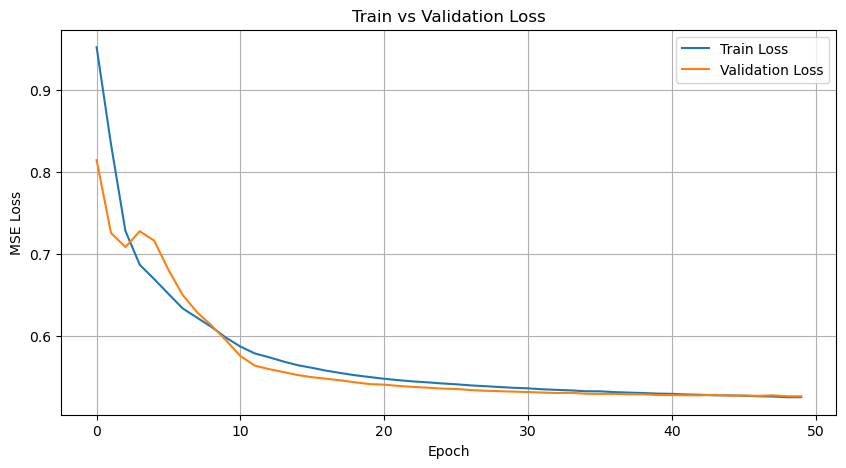

In [46]:


plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
def get_reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    err = np.mean((X - X_pred) ** 2, axis=(1, 2))
    return err

train_scores = get_reconstruction_error(model, X_train_ae)
val_scores   = get_reconstruction_error(model, X_val_ae)
full_scores  = get_reconstruction_error(model, X_full)

meta_full['raw_score'] = full_scores

In [48]:
def apply_ema(meta_df, alpha=0.4):
    meta_df = meta_df.sort_values(['engine_id', 'cycle']).copy()
    smooth_scores = []

    for eng, group in meta_df.groupby('engine_id'):
        prev = None
        for score in group['raw_score']:
            if prev is None:
                sm = score
            else:
                sm = alpha * score + (1 - alpha) * prev
            smooth_scores.append(sm)
            prev = sm

    meta_df['smooth_score'] = smooth_scores
    return meta_df

meta_full = apply_ema(meta_full, alpha=0.4)

In [49]:
warning_th = np.percentile(val_scores, 97)
critical_th = np.percentile(val_scores, 99.5)

print("warning_th :", warning_th)
print("critical_th:", critical_th)

warning_th : 0.5825361046860498
critical_th: 0.6093226125143913


In [50]:
from sklearn.metrics import roc_auc_score

meta_full['unstable_true'] = (meta_full['RUL'] <= 30).astype(int)

auc = roc_auc_score(meta_full['unstable_true'], meta_full['smooth_score'])
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.9696


In [ ]:
def get_state(score, warning_th, critical_th):
    if score < warning_th:
        return "stable"
    elif score < critical_th:
        return "warning"
    else:
        return "critical"

meta_full['state'] = meta_full['smooth_score'].apply(
    lambda x: get_state(x, warning_th, critical_th)
)

meta_full[['engine_id', 'cycle', 'RUL', 'raw_score', 'smooth_score', 'state']].head()

,engine_id,cycle,RUL,raw_score,smooth_score,state
0,1,25,167.0,0.522213,0.522213,stable
1,1,26,166.0,0.520152,0.521595,stable
2,1,27,165.0,0.523875,0.522279,stable
3,1,28,164.0,0.535536,0.526256,stable
4,1,29,163.0,0.518782,0.524014,stable
5,1,30,162.0,0.541886,0.529376,stable
6,1,31,161.0,0.541938,0.533144,stable
7,1,32,160.0,0.551106,0.538533,stable
8,1,33,159.0,0.552319,0.542669,stable
9,1,34,158.0,0.547147,0.544012,stable


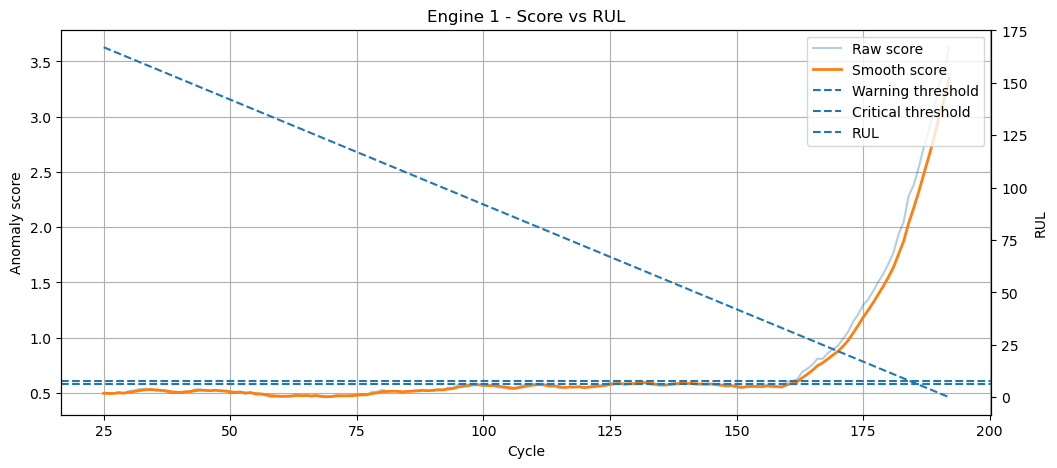

In [51]:
def plot_engine(meta_df, engine_id_plot):
    df_plot = meta_df[meta_df['engine_id'] == engine_id_plot].sort_values('cycle')

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(df_plot['cycle'], df_plot['raw_score'], alpha=0.35, label='Raw score')
    ax1.plot(df_plot['cycle'], df_plot['smooth_score'], linewidth=2, label='Smooth score')
    ax1.axhline(warning_th, linestyle='--', label='Warning threshold')
    ax1.axhline(critical_th, linestyle='--', label='Critical threshold')
    ax1.set_xlabel('Cycle')
    ax1.set_ylabel('Anomaly score')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(df_plot['cycle'], df_plot['RUL'], linestyle='--', label='RUL')
    ax2.set_ylabel('RUL')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.title(f'Engine {engine_id_plot} - Score vs RUL')
    plt.show()

plot_engine(meta_full, 1)